In [ ]:
# Model-free Kalman filtering code (translated from MATLAB)

from dataclasses import dataclass
from typing import Callable, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import expm

In [ ]:
@dataclass
class Params:
    Fx: float = 10.0
    Fy: float = 0.0
    a_true: float = 1.0
    a_model: float = 1.0
    Nx: int = 40
    Ny: int = 10
    eps: float = 0.1
    hx: float = -1.0
    hy: float = 1.0
    Kinit: int = 500
    Ktrain: int = 1000
    Ktest: int = 200
    dt: float = 0.05
    D: int = 2
    nu: int = 2
    tau: int = 4
    Nnn: int = 100


def chol_psd(a: np.ndarray, jitter: float = 1e-10) -> np.ndarray:
    a_sym = 0.5 * (a + a.T)
    for k in range(8):
        try:
            return np.linalg.cholesky(a_sym + (10**k) * jitter * np.eye(a.shape[0]))
        except np.linalg.LinAlgError:
            pass
    w, v = np.linalg.eigh(a_sym)
    w = np.clip(w, 1e-12, None)
    return v @ np.diag(np.sqrt(w))


def intdyn(dynamics: Callable[[float, np.ndarray], np.ndarray], xpre: np.ndarray, T: float) -> np.ndarray:
    sol = solve_ivp(
        dynamics,
        (0.0, T),
        xpre,
        method="BDF",
        rtol=1e-4,
        atol=1e-4,
        t_eval=[T],
    )
    if not sol.success:
        raise RuntimeError(f"Integration failed: {sol.message}")
    return sol.y[:, -1]


def l96SS(_t: float, X: np.ndarray, a: float, p: Params) -> np.ndarray:
    dX = np.zeros(p.Nx)
    dX[0] = (X[1] - a * X[-2]) * X[-1] - X[0] + p.Fx
    dX[1] = (X[2] - a * X[-1]) * X[0] - X[1] + p.Fx
    dX[-1] = (X[0] - a * X[-3]) * X[-2] - X[-1] + p.Fx
    for i in range(2, p.Nx - 1):
        dX[i] = (X[i + 1] - a * X[i - 2]) * X[i - 1] - X[i] + p.Fx
    return dX


def l96SS_TLM(_t: float, X: np.ndarray, a: float, p: Params) -> np.ndarray:
    Nx = p.Nx
    J = np.zeros((Nx, Nx))

    J[0, 0] = -1.0
    J[0, 1] = X[-1]
    J[0, -2] = -a * X[-1]
    J[0, -1] = X[1] - a * X[-2]

    J[1, 0] = X[2] - a * X[-1]
    J[1, 1] = -1.0
    J[1, 2] = X[0]
    J[1, -1] = -a * X[0]

    J[-1, 0] = X[-2]
    J[-1, -3] = -a * X[-2]
    J[-1, -2] = X[0] - a * X[-3]
    J[-1, -1] = -1.0

    for i in range(2, Nx - 1):
        J[i, i - 2] = -a * X[i - 1]
        J[i, i - 1] = X[i + 1] - a * X[i - 2]
        J[i, i] = -1.0
        J[i, i + 1] = X[i - 1]

    return J


def l96MS(_t: float, X: np.ndarray, a: float, p: Params) -> np.ndarray:
    Nx, Ny = p.Nx, p.Ny

    x = np.zeros(Nx + 4)
    x[2:2 + Nx] = X[:Nx]
    x[:2] = X[Nx - 2:Nx]
    x[-2:] = X[:2]

    Y = X[Nx:Nx * (Ny + 1)].reshape((Nx, Ny), order="F")
    y = np.vstack([Y[-1:, :], Y, Y[:1, :]])

    dx = np.zeros(Nx)
    dy = np.zeros((Nx, Ny))

    for n in range(Nx):
        nx = n + 2
        ny = n + 1

        dx[n] = (x[nx + 1] - a * x[nx - 2]) * x[nx - 1] - x[nx] + p.Fx + p.hx * np.mean(y[ny, :])

        dy[n, 0] = (y[ny - 1, Ny - 1] - y[ny, 2]) * y[ny, 1] - y[ny, 0] + p.Fy + p.hy * x[nx]
        dy[n, Ny - 2] = (y[ny, Ny - 3] - y[ny + 1, 0]) * y[ny, Ny - 1] - y[ny, Ny - 2] + p.Fy + p.hy * x[nx]
        dy[n, Ny - 1] = (y[ny, Ny - 2] - y[ny + 1, 1]) * y[ny + 1, 0] - y[ny, Ny - 1] + p.Fy + p.hy * x[nx]

        for j in range(1, Ny - 2):
            dy[n, j] = (y[ny, j - 1] - y[ny, j + 2]) * y[ny, j + 1] - y[ny, j] + p.Fy + p.hy * x[nx]

    return np.concatenate([dx, dy.reshape(-1, order="F") / p.eps])


def gaspari_cohn(Nx: int, radius: float) -> np.ndarray:
    D = np.abs(np.arange(Nx)[:, None] - np.arange(Nx)[None, :])
    r = np.minimum(D, Nx - D) / radius

    rho = np.zeros((Nx, Nx))

    mask_r01 = r < 1
    rr = r[mask_r01]
    rho[mask_r01] = 1 - (5 / 3) * rr**2 + (5 / 8) * rr**3 + 0.5 * rr**4 - 0.25 * rr**5

    mask_r12 = (r >= 1) & (r < 2)
    rr = r[mask_r12]
    rho[mask_r12] = 4 - 5 * rr + (5 / 3) * rr**2 + (5 / 8) * rr**3 - 0.5 * rr**4 + (1 / 12) * rr**5 - 2 / (3 * rr)

    return rho


def nearneighM(xpre: np.ndarray, x_embed: np.ndarray, Nnn: int) -> np.ndarray:
    xpre = np.asarray(xpre).reshape(-1)
    Nemb, Nx, T = x_embed.shape

    Xdpre = np.reshape(x_embed[:, :, :-1], (Nemb, Nx * (T - 1)), order="F").T
    Xdpost = np.reshape(x_embed[:, :, 1:], (Nemb, Nx * (T - 1)), order="F").T

    d_ij = np.linalg.norm(Xdpre - xpre[None, :], axis=1)
    dist_idxs = np.argsort(d_ij)
    kneig_idxs = dist_idxs[:Nnn]

    Xfut_neig = Xdpost[kneig_idxs, :]
    Xmat = np.hstack([np.ones((Nnn, 1)), Xdpre[kneig_idxs, :]])
    alphas, *_ = np.linalg.lstsq(Xmat, Xfut_neig, rcond=None)
    xpost = np.hstack([1.0, xpre]) @ alphas
    return xpost


def embed_TLM(xa: np.ndarray, x_embed: np.ndarray, Nnn: int) -> np.ndarray:
    delta = 1e-8
    N = xa.size
    TLM = np.zeros((N, N))

    for i in range(N):
        xp = xa.copy()
        xm = xa.copy()
        xp[i] += delta
        xm[i] -= delta
        fp = nearneighM(xp, x_embed, Nnn)
        fm = nearneighM(xm, x_embed, Nnn)
        TLM[:, i] = (fp - fm) / (2 * delta)
    return TLM


def ex_mbss_f(xa: np.ndarray, Pa: np.ndarray, Q: np.ndarray, p: Params) -> Tuple[np.ndarray, np.ndarray]:
    xf = intdyn(lambda t, X: l96SS(t, X, p.a_model, p), xa, p.dt)
    TLM = expm(l96SS_TLM(0.0, xa, p.a_model, p) * p.dt)
    Pf = TLM @ Pa @ TLM.T + Q
    return xf, Pf


def ex_mb_a(xf: np.ndarray, Pf: np.ndarray, y: np.ndarray, H: np.ndarray, R: np.ndarray, rho: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Nx = xf.size
    Kk = (rho * (Pf @ H.T)) @ np.linalg.inv(H @ Pf @ H.T + R)
    xa = xf + Kk @ (y - H @ xf)
    Pa = (np.eye(Nx) - Kk @ H) @ Pf
    return xa, Pa


def ex_mf_f(xa: np.ndarray, Pa: np.ndarray, x_embed: np.ndarray, Nnn: int, Q: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Nemb, Nx = xa.shape
    xf = np.zeros_like(xa)
    Pf = np.zeros((Nemb, Nemb, Nx))

    for i in range(Nx):
        xf[:, i] = nearneighM(xa[:, i], x_embed, Nnn)
        TLM = embed_TLM(xa[:, i], x_embed, Nnn)
        Pf[:, :, i] = TLM @ Pa[:, :, i] @ TLM.T + Q

    return xf, Pf


def ex_mf_a(xf: np.ndarray, Pf: np.ndarray, y: np.ndarray, H: np.ndarray, R: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Nemb, Nx = xf.shape
    xa = np.zeros_like(xf)
    Pa = np.zeros((Nemb, Nemb, Nx))

    for i in range(Nx):
        Hi = H[:, :, i]
        Kk = Pf[:, :, i] @ Hi.T @ np.linalg.inv(Hi @ Pf[:, :, i] @ Hi.T + R)
        xa[:, i] = xf[:, i] + Kk @ (y[:, i] - Hi @ xf[:, i])
        Pa[:, :, i] = (np.eye(Nemb) - Kk @ Hi) @ Pf[:, :, i]

    return xa, Pa


def en_mbss_f(xai: np.ndarray, Q: np.ndarray, p: Params, rng: np.random.Generator) -> np.ndarray:
    Nx, Nens = xai.shape
    xfi = np.zeros_like(xai)
    noise = rng.multivariate_normal(np.zeros(Nx), Q, size=Nens).T

    for i in range(Nens):
        xfi[:, i] = intdyn(lambda t, X: l96SS(t, X, p.a_model, p), xai[:, i], p.dt) + noise[:, i]

    return xfi


def en_mb_a(xfi: np.ndarray, y: np.ndarray, H: np.ndarray, variance: float, mu_inf: float, rho: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    Nens = xfi.shape[1]
    xfbar = np.mean(xfi, axis=1, keepdims=True)
    Pf = (xfi - xfbar) @ (xfi - xfbar).T / (Nens - 1)

    ui = rng.normal(0.0, np.sqrt(variance), size=xfi.shape)
    ui -= np.mean(ui, axis=1, keepdims=True)
    Ru = (ui @ ui.T) / (Nens - 1)

    yi = y[:, None] + ui
    Kk = (rho * (Pf @ H.T)) @ np.linalg.inv(H @ Pf @ H.T + Ru)

    xai = xfi + Kk @ (yi - H @ xfi)
    xabar = np.mean(xai, axis=1, keepdims=True)
    xai = xabar + mu_inf * (xai - xabar)
    return xai


def en_mf_f(xai: np.ndarray, x_embed: np.ndarray, Nnn: int, Q: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    Nemb, Nx, Nens = xai.shape
    xfi = np.zeros_like(xai)

    for i in range(Nx):
        noise = rng.multivariate_normal(np.zeros(Nemb), Q, size=Nens)
        for j in range(Nens):
            xfi[:, i, j] = nearneighM(xai[:, i, j], x_embed, Nnn) + noise[j, :]

    return xfi


def en_mf_a(xfi: np.ndarray, y: np.ndarray, H: np.ndarray, variance: float, rng: np.random.Generator) -> np.ndarray:
    Nemb, Nx, Nens = xfi.shape
    xai = np.zeros_like(xfi)

    for i in range(Nx):
        xfi_i = xfi[:, i, :]
        xfbari = np.mean(xfi_i, axis=1, keepdims=True)
        Pfi = (xfi_i - xfbari) @ (xfi_i - xfbari).T / (Nens - 1)

        ui = rng.normal(0.0, np.sqrt(variance), size=(Nemb, Nens))
        ui -= np.mean(ui, axis=1, keepdims=True)
        Ru = (ui @ ui.T) / (Nens - 1)

        yi = y[:, i][:, None] + ui
        Hi = H[:, :, i]
        Kki = Pfi @ Hi.T @ np.linalg.inv(Hi @ Pfi @ Hi.T + Ru)
        xai[:, i, :] = xfi_i + Kki @ (yi - Hi @ xfi_i)

    return xai


def u_mb_f(xa: np.ndarray, Pa: np.ndarray, lambda_un: float, Wm: np.ndarray, Wc: np.ndarray, Q: np.ndarray, p: Params) -> Tuple[np.ndarray, np.ndarray]:
    Nx = xa.size
    xfi = np.zeros((Nx, 2 * Nx + 1))

    pert = np.sqrt(Nx + lambda_un) * chol_psd(Pa)
    sig = np.concatenate([xa[:, None], xa[:, None] + pert, xa[:, None] - pert], axis=1)

    for i in range(2 * Nx + 1):
        xfi[:, i] = intdyn(lambda t, X: l96SS(t, X, p.a_model, p), sig[:, i], p.dt)

    Pf = Q.copy()
    xmean = xfi @ Wm
    for i in range(2 * Nx + 1):
        diff = xfi[:, i] - xmean
        Pf += Wc[i] * np.outer(diff, diff)

    return xfi, Pf


def u_mb_a(xfi: np.ndarray, Pf: np.ndarray, y: np.ndarray, H: np.ndarray, Wm: np.ndarray, Wc: np.ndarray, R: np.ndarray, rho: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Nx = xfi.shape[0]

    yfi = H @ xfi
    ymean = yfi @ Wm
    xmean = xfi @ Wm

    Pyy = R.copy()
    Pxy = np.zeros((Nx, Nx))
    for i in range(2 * Nx + 1):
        ydiff = yfi[:, i] - ymean
        xdiff = xfi[:, i] - xmean
        Pyy += Wc[i] * np.outer(ydiff, ydiff)
        Pxy += Wc[i] * np.outer(xdiff, ydiff)

    Kk = (rho * Pxy) @ np.linalg.inv(Pyy)
    xa = xmean + Kk @ (y - ymean)

    I = np.eye(Nx)
    Pa = (I - Kk @ H) @ Pf @ (I - Kk @ H).T + Kk @ R @ Kk.T
    Pa = 0.5 * (Pa + Pa.T)
    return xa, Pa


def u_mf_f(
    xa: np.ndarray,
    Pa: np.ndarray,
    x_embed: np.ndarray,
    Nnn: int,
    lambda_un: float,
    Wm: np.ndarray,
    Wc: np.ndarray,
    Q: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    Nemb, Nx = xa.shape
    xfi = np.zeros((Nemb, Nx, 2 * Nemb + 1))

    for i in range(Nx):
        xai = xa[:, i]
        pert = np.sqrt(Nemb + lambda_un) * chol_psd(Pa[:, :, i])
        sig = np.concatenate([xai[:, None], xai[:, None] + pert, xai[:, None] - pert], axis=1)
        for j in range(2 * Nemb + 1):
            xfi[:, i, j] = nearneighM(sig[:, j], x_embed, Nnn)

    Pf = np.repeat(Q[:, :, None], Nx, axis=2)
    for i in range(Nx):
        xmean = xfi[:, i, :] @ Wm
        for j in range(2 * Nemb + 1):
            diff = xfi[:, i, j] - xmean
            Pf[:, :, i] += Wc[j] * np.outer(diff, diff)

    return xfi, Pf


def u_mf_a(xfi: np.ndarray, Pf: np.ndarray, y: np.ndarray, H: np.ndarray, Wm: np.ndarray, Wc: np.ndarray, R: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Nemb, Nx, _ = xfi.shape
    xa = np.zeros((Nemb, Nx))
    Pa = np.zeros((Nemb, Nemb, Nx))

    for i in range(Nx):
        Hi = H[:, :, i]
        xfi_i = xfi[:, i, :]
        yfi = Hi @ xfi_i

        ymean = yfi @ Wm
        xmean = xfi_i @ Wm

        Pyy = R.copy()
        Pxy = np.zeros((Nemb, Nemb))
        for j in range(2 * Nemb + 1):
            ydiff = yfi[:, j] - ymean
            xdiff = xfi_i[:, j] - xmean
            Pyy += Wc[j] * np.outer(ydiff, ydiff)
            Pxy += Wc[j] * np.outer(xdiff, ydiff)

        Kk = Pxy @ np.linalg.inv(Pyy)
        xa[:, i] = xmean + Kk @ (y[:, i] - ymean)

        I = np.eye(Nemb)
        Pa[:, :, i] = (I - Kk @ Hi) @ Pf[:, :, i] @ (I - Kk @ Hi).T + Kk @ R @ Kk.T
        Pa[:, :, i] = 0.5 * (Pa[:, :, i] + Pa[:, :, i].T)

    return xa, Pa


def _nonzeros_colmajor(a: np.ndarray) -> np.ndarray:
    v = np.ravel(a, order="F")
    return v[v != 0]


def _assign_by_mask_colmajor(target: np.ndarray, mask: np.ndarray, values: np.ndarray) -> np.ndarray:
    flat_t = np.ravel(target, order="F")
    flat_m = np.ravel(mask.astype(bool), order="F")
    idx = np.where(flat_m)[0]

    values = np.asarray(values).reshape(-1)
    if values.size != idx.size:
        raise ValueError(f"Value size {values.size} does not match mask size {idx.size}")

    flat_t[idx] = values
    return np.reshape(flat_t, target.shape, order="F")


def nudge(x: np.ndarray, mask_embed_equivalent: np.ndarray, gamma: float, D: int, nu: int, Nx: int) -> np.ndarray:
    gamma = 1.0 - gamma
    NU = [0] + list(range(-nu, 0)) + list(range(1, nu + 1))

    for i in range(1, Nx + 1):
        x_local_eq = x.copy()
        shifted = np.roll(x_local_eq, shift=-i + 1, axis=1)
        vec = _nonzeros_colmajor(shifted * mask_embed_equivalent)

        local = vec.reshape((D + 1, len(NU)), order="F")
        local_mean = local.mean(axis=1)
        rep_mean = np.tile(local_mean, len(NU))
        upd = rep_mean + gamma * (vec - rep_mean)

        if i == 1:
            shift = 0
        elif i == 2:
            shift = D + 1
        elif 2 < i < Nx - 1:
            shift = 2 * (D + 1)
        elif i == Nx - 1:
            shift = 3 * (D + 1)
        else:
            shift = 4 * (D + 1)

        upd = np.roll(upd, shift)
        mask_i = np.roll(mask_embed_equivalent == 1, shift=i - 1, axis=1)
        x = _assign_by_mask_colmajor(x_local_eq, mask_i, upd)

    return x


def cumulative_rmse(x_true: np.ndarray, x_est: np.ndarray) -> np.ndarray:
    err2 = (x_true - x_est) ** 2
    csum = np.cumsum(err2, axis=1)
    denom = np.arange(1, err2.shape[1] + 1)
    return np.sqrt(np.mean(csum / denom[None, :], axis=0))

In [7]:
# Parameters

p = Params()
rng = np.random.default_rng(0)

Nemb = (2 * p.nu + 1) * (p.D + 1)
Nnn = p.Nnn
var_index = 1

In [8]:
# Generate and process data

x0 = rng.uniform(0.0, 1.0, size=p.Nx * (p.Ny + 1))
t_eval = np.arange(0.0, p.dt * (p.Kinit + p.Ktrain + p.Ktest) + 0.5 * p.dt, p.dt)

sol = solve_ivp(
    lambda t, X: l96MS(t, X, p.a_true, p),
    (t_eval[0], t_eval[-1]),
    x0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-9,
)
if not sol.success:
    raise RuntimeError(sol.message)

X_full = sol.y.T
X_true = X_full[p.Kinit : p.Kinit + p.Ktrain + p.Ktest, :].T
x_true = X_true[: p.Nx, :]

variance_vec = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
variance = variance_vec[var_index - 1]

x_noisy = x_true + rng.normal(0.0, np.sqrt(variance), size=(p.Nx, p.Ktrain + p.Ktest))
x_train = x_noisy[:, : p.Ktrain]
x_test = x_noisy[:, p.Ktrain :]

In [26]:
# Remove observations

S = 8
base = np.repeat(np.eye(p.Nx), S, axis=1)
reps = int(np.ceil((p.Ktest + p.D * p.tau) / (S * p.Nx)))
mask_sat = np.tile(base, (1, reps))

mask0 = mask_sat[:, : p.Ktest + p.D * p.tau]
mask = (
    mask0
    + np.roll(mask0, 10, axis=0)
    + np.roll(mask0, 20, axis=0)
    + np.roll(mask0, 30, axis=0)
)

mask_delay = mask.copy()
mask = mask[:, p.D * p.tau :]

y = x_test * mask
y_delay = x_noisy[:, p.Ktrain - p.D * p.tau :] * mask_delay

In [27]:
# Populate embedded vectors

x_embed = np.zeros((Nemb, p.Nx, p.Ktrain - p.D * p.tau))
x_true_embed_1 = np.zeros((Nemb, p.Nx))
y_embed = np.zeros((Nemb, p.Nx, p.Ktest))
mask_embed = np.zeros((Nemb, p.Nx, p.Ktest))
mask_embed_equivalent = np.zeros((Nemb, p.Nx))

NU = [0] + list(range(-p.nu, 0)) + list(range(1, p.nu + 1))
count = 0

for n, shift in enumerate(NU):
    for d in range(p.D + 1):
        start = (p.D - d) * p.tau
        end_train = x_train.shape[1] - d * p.tau
        end_delay = y_delay.shape[1] - d * p.tau

        x_embed[count, :, :] = np.roll(x_train[:, start:end_train], shift, axis=0)
        x_true_embed_1[count, :] = np.roll(x_true[:, p.Ktrain - d * p.tau], shift, axis=0)
        y_embed[count, :, :] = np.roll(y_delay[:, start:end_delay], shift, axis=0)
        mask_embed[count, :, :] = np.roll(mask_delay[:, start:end_delay], shift, axis=0)
        count += 1

    row_idx = np.arange(p.D + 1) + n * (p.D + 1)
    col = shift if shift >= 0 else p.Nx + shift
    mask_embed_equivalent[row_idx, col] = 1

In [ ]:
# Initialise

Q = 0.5 * np.eye(p.Nx)
Q_embed = 0.5 * np.eye(Nemb)
R = variance * np.eye(p.Nx)
R_embed = variance * np.eye(Nemb)
H = np.eye(p.Nx)
H_emb = np.eye(Nemb)

x_ex_mb_a = np.zeros((p.Nx, p.Ktest))
x_ex_mb_a[:, 0] = x_true[:, p.Ktrain]

x_ex_mf_a = np.zeros((Nemb, p.Nx, p.Ktest))
x_ex_mf_a[:, :, 0] = x_true_embed_1

Nens_mb = 100
mu_inf_mb = 1.02
x_en_mb_a_bar = np.zeros((p.Nx, p.Ktest))
u1 = rng.normal(0.0, np.sqrt(variance), size=(p.Nx, Nens_mb))
u1 -= u1.mean(axis=1, keepdims=True)
x_en_mb_a = x_true[:, [p.Ktrain]] + u1
x_en_mb_a_bar[:, 0] = x_true[:, p.Ktrain]

Nens_mf = 100
mu_inf_mf = 1.0
x_en_mf_a_bar = np.zeros((Nemb, p.Nx, p.Ktest))
u1_embed = rng.normal(0.0, np.sqrt(variance), size=(Nemb, p.Nx, Nens_mf))
u1_embed -= u1_embed.mean(axis=2, keepdims=True)
x_en_mf_a = x_true_embed_1[:, :, None] + u1_embed
x_en_mf_a_bar[:, :, 0] = x_true_embed_1

alpha_un = 0.01
beta_un = 2.0
kappa_un = 0.0
lambda_un = alpha_un**2 * (p.Nx + kappa_un) - p.Nx
x_un_mb_a = np.zeros((p.Nx, p.Ktest))
x_un_mb_a[:, 0] = x_true[:, p.Ktrain]

Wm = np.hstack([lambda_un / (lambda_un + p.Nx), (0.5 / (lambda_un + p.Nx)) * np.ones(2 * p.Nx)])
Wc = Wm.copy()
Wc[0] += 1 - alpha_un**2 + beta_un

alpha_un_embed = 1.0
kappa_un_embed = 0.0
x_un_mf_a = np.zeros((Nemb, p.Nx, p.Ktest))
x_un_mf_a[:, :, 0] = x_true_embed_1
lambda_un_embed = alpha_un_embed**2 * (Nemb + kappa_un_embed) - Nemb
Wm_embed = np.hstack([
    lambda_un_embed / (lambda_un_embed + Nemb),
    (0.5 / (lambda_un_embed + Nemb)) * np.ones(2 * Nemb),
])
Wc_embed = Wm_embed.copy()
Wc_embed[0] += 1 - alpha_un_embed**2 + beta_un

gamma = 0.9

P_ex_mb_a = R.copy()
P_ex_mf_a = np.repeat(R_embed[:, :, None], p.Nx, axis=2)
P_un_mb_a = R.copy()
P_un_mf_a = np.repeat(R_embed[:, :, None], p.Nx, axis=2)

rho = gaspari_cohn(p.Nx, 5)

# error catches
ex_mb = en_mb = un_mb = False
ex_mf = en_mf = un_mf = False

In [29]:
# Forecast/analysis loop

for kk in range(1, p.Ktest):
    if not ex_mb:
        x_ex_mb_f, P_ex_mb_f = ex_mbss_f(x_ex_mb_a[:, kk - 1], P_ex_mb_a, Q, p)

    if not ex_mf:
        x_ex_mf_f, P_ex_mf_f = ex_mf_f(x_ex_mf_a[:, :, kk - 1], P_ex_mf_a, x_embed, Nnn, Q_embed)

    if not en_mb:
        x_en_mb_f = en_mbss_f(x_en_mb_a, Q, p, rng)

    if not en_mf:
        x_en_mf_f = en_mf_f(x_en_mf_a, x_embed, Nnn, Q_embed, rng)

    if not un_mb:
        x_un_mb_f, P_un_mb_f = u_mb_f(x_un_mb_a[:, kk - 1], P_un_mb_a, lambda_un, Wm, Wc, Q, p)

    if not un_mf:
        x_un_mf_f, P_un_mf_f = u_mf_f(
            x_un_mf_a[:, :, kk - 1],
            P_un_mf_a,
            x_embed,
            Nnn,
            lambda_un_embed,
            Wm_embed,
            Wc_embed,
            Q_embed,
        )

    if not ex_mb:
        Hk = np.diag(mask[:, kk]) @ H
        x_ex_mb_a[:, kk], P_ex_mb_a = ex_mb_a(x_ex_mb_f, P_ex_mb_f, y[:, kk], Hk, R, rho)

    if not ex_mf:
        H_mf = mask_embed[:, :, kk][:, None, :] * H_emb[:, :, None]
        x_ex_mf_a[:, :, kk], P_ex_mf_a = ex_mf_a(x_ex_mf_f, P_ex_mf_f, y_embed[:, :, kk], H_mf, R_embed)

    if not en_mb:
        Hk = np.diag(mask[:, kk]) @ H
        x_en_mb_a = en_mb_a(x_en_mb_f, y[:, kk], Hk, variance, mu_inf_mb, rho, rng)
        x_en_mb_a_bar[:, kk] = x_en_mb_a.mean(axis=1)

    if not en_mf:
        H_mf = mask_embed[:, :, kk][:, None, :] * H_emb[:, :, None]
        x_en_mf_a = en_mf_a(x_en_mf_f, y_embed[:, :, kk], H_mf, variance, rng)

    if not un_mb:
        Hk = np.diag(mask[:, kk]) @ H
        x_un_mb_a[:, kk], P_un_mb_a = u_mb_a(x_un_mb_f, P_un_mb_f, y[:, kk], Hk, Wm, Wc, R, rho)

    if not un_mf:
        H_mf = mask_embed[:, :, kk][:, None, :] * H_emb[:, :, None]
        x_un_mf_a[:, :, kk], P_un_mf_a = u_mf_a(
            x_un_mf_f,
            P_un_mf_f,
            y_embed[:, :, kk],
            H_mf,
            Wm_embed,
            Wc_embed,
            R_embed,
        )

    if not ex_mf:
        x_ex_mf_a[:, :, kk] = nudge(x_ex_mf_a[:, :, kk], mask_embed_equivalent, gamma, p.D, p.nu, p.Nx)

    if not en_mf:
        for n in range(Nens_mf):
            x_en_mf_a[:, :, n] = nudge(x_en_mf_a[:, :, n], mask_embed_equivalent, gamma, p.D, p.nu, p.Nx)

        for i in range(p.Nx):
            xabari = x_en_mf_a.mean(axis=1, keepdims=True)
            x_en_mf_a[:, i : i + 1, :] = xabari + mu_inf_mf * (x_en_mf_a[:, i : i + 1, :] - xabari)

    if not un_mf:
        x_un_mf_a[:, :, kk] = nudge(x_un_mf_a[:, :, kk], mask_embed_equivalent, gamma, p.D, p.nu, p.Nx)

    if not en_mf:
        x_en_mf_a_bar[:, :, kk] = x_en_mf_a.mean(axis=2)

    if (not ex_mb) and np.any(np.abs(x_ex_mb_a[:, kk]) > 1000):
        ex_mb = True
    if (not en_mb) and np.any(np.abs(x_en_mb_a) > 1000):
        en_mb = True
    if (not un_mb) and np.any(np.abs(x_un_mb_a[:, kk]) > 1000):
        un_mb = True
    if (not ex_mf) and np.any(np.abs(x_ex_mf_a[:, :, kk]) > 1000):
        ex_mf = True
    if (not en_mf) and np.any(np.abs(x_en_mf_a) > 1000):
        en_mf = True
    if (not un_mf) and np.any(np.abs(x_un_mf_a[:, :, kk]) > 1000):
        un_mf = True

KeyboardInterrupt: 

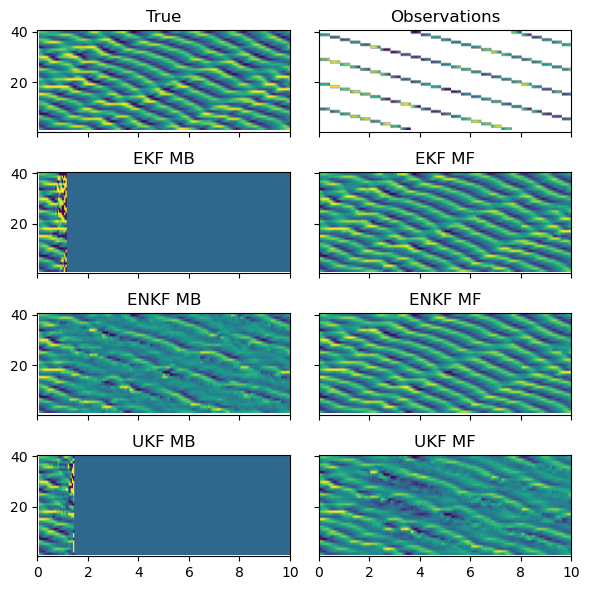

In [ ]:
yplot = y.copy()
yplot[yplot == 0] = np.nan

t = np.arange(1, p.Ktest + 1) * p.dt
vmin, vmax = -5, 10

fig, axs = plt.subplots(4, 2, figsize=(6, 6), sharex=True, sharey=True)
cmap = plt.get_cmap("viridis")

axs[0,0].imshow(x_true[:, p.Ktrain:], aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[0,0].set_title("True")
axs[0,0].set_xlim(0, 10)
axs[0,0].set_ylim(0.5, p.Nx + 0.5)
axs[0,1].imshow(yplot, aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[0,1].set_title("Observations")
axs[0,1].set_xlim(0, 10)
axs[0,1].set_ylim(0.5, p.Nx + 0.5)
axs[1,0].imshow(x_ex_mb_a, aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[1,0].set_title("EKF MB")
axs[1,0].set_xlim(0, 10)
axs[1,0].set_ylim(0.5, p.Nx + 0.5)
axs[2,0].imshow(x_en_mb_a_bar, aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[2,0].set_title("ENKF MB")
axs[2,0].set_xlim(0, 10)
axs[2,0].set_ylim(0.5, p.Nx + 0.5)
axs[3,0].imshow(x_un_mb_a, aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[3,0].set_title("UKF MB")
axs[3,0].set_xlim(0, 10)
axs[3,0].set_ylim(0.5, p.Nx + 0.5)
axs[1,1].imshow(x_ex_mf_a[0, :, :], aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[1,1].set_title("EKF MF")
axs[1,1].set_xlim(0, 10)
axs[1,1].set_ylim(0.5, p.Nx + 0.5)
axs[2,1].imshow(x_en_mf_a_bar[0, :, :], aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[2,1].set_title("ENKF MF")
axs[2,1].set_xlim(0, 10)
axs[2,1].set_ylim(0.5, p.Nx + 0.5)
axs[3,1].imshow(x_un_mf_a[0, :, :], aspect="auto", origin="lower", extent=[t[0], t[-1], 1, p.Nx], vmin=vmin, vmax=vmax, cmap=cmap)
axs[3,1].set_title("UKF MF")
axs[3,1].set_xlim(0, 10)
axs[3,1].set_ylim(0.5, p.Nx + 0.5)

fig.tight_layout()
plt.show()

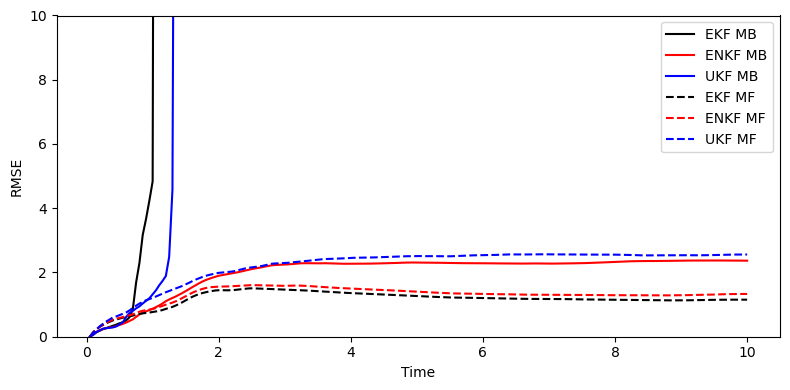

In [ ]:
RMSE_ex_mb = cumulative_rmse(x_true[:, p.Ktrain:], x_ex_mb_a)
RMSE_en_mb = cumulative_rmse(x_true[:, p.Ktrain:], x_en_mb_a_bar)
RMSE_un_mb = cumulative_rmse(x_true[:, p.Ktrain:], x_un_mb_a)
RMSE_ex_mf = cumulative_rmse(x_true[:, p.Ktrain:], x_ex_mf_a[0, :, :])
RMSE_en_mf = cumulative_rmse(x_true[:, p.Ktrain:], x_en_mf_a_bar[0, :, :])
RMSE_un_mf = cumulative_rmse(x_true[:, p.Ktrain:], x_un_mf_a[0, :, :])

plt.figure(figsize=(8, 4))
plt.plot(t, RMSE_ex_mb, "k-", label="EKF MB")
plt.plot(t, RMSE_en_mb, "r-", label="ENKF MB")
plt.plot(t, RMSE_un_mb, "b-", label="UKF MB")
plt.plot(t, RMSE_ex_mf, "k--", label="EKF MF")
plt.plot(t, RMSE_en_mf, "r--", label="ENKF MF")
plt.plot(t, RMSE_un_mf, "b--", label="UKF MF")
plt.ylim(0,10)
plt.xlabel("Time")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()